In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

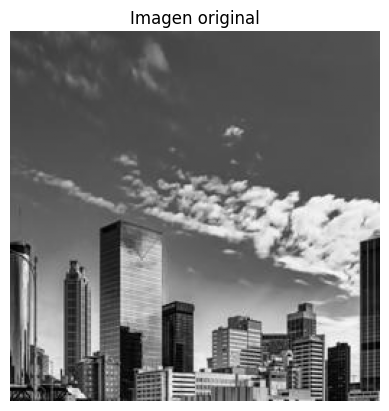

In [2]:
# cargar imagen
img = Image.open("img_ejemplo_256.jpg")

# convertir a escala de grises
img_gray = img.convert("L")

# convertir a matriz numpy
image = np.array(img_gray)

# mostrar imagen
plt.imshow(image, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

In [8]:
image.shape

(256, 256)

Es como si fuera (256,256,1)

In [3]:
print("Dimensiones de la imagen:", image.shape)

# ver parte de la matriz
image[:10,:10]

Dimensiones de la imagen: (256, 256)


array([[64, 63, 62, 62, 62, 61, 60, 58, 61, 61],
       [66, 64, 62, 62, 62, 62, 61, 60, 62, 62],
       [68, 66, 63, 62, 62, 63, 62, 61, 62, 62],
       [71, 68, 65, 63, 63, 63, 63, 62, 61, 61],
       [72, 70, 67, 66, 65, 65, 64, 62, 62, 62],
       [74, 73, 71, 70, 70, 69, 66, 65, 64, 64],
       [77, 76, 76, 76, 76, 74, 70, 67, 67, 67],
       [80, 80, 80, 81, 81, 78, 73, 70, 70, 71],
       [78, 79, 81, 83, 83, 81, 79, 78, 73, 72],
       [76, 77, 79, 81, 82, 81, 79, 78, 74, 75]], dtype=uint8)

In [4]:
image.shape

(256, 256)

In [ ]:
def convolution(image, kernel, stride=1, padding=0):

    if padding > 0:
        image = np.pad(image, ((padding,padding),(padding,padding)), mode='constant')

    kernel_size = kernel.shape[0]

    output_height = (image.shape[0] - kernel_size)//stride + 1
    output_width = (image.shape[1] - kernel_size)//stride + 1

    output = np.zeros((output_height, output_width))

    for y in range(output_height):
        for x in range(output_width):

            region = image[
                y*stride:y*stride+kernel_size,
                x*stride:x*stride+kernel_size
            ]

            output[y,x] = np.sum(region * kernel)

    return output

In [ ]:
kernel_vertical = np.array([
    [1,0,-1],
    [1,0,-1],
    [1,0,-1]
])

In [ ]:
vertical_edges = convolution(image, kernel_vertical)

plt.imshow(vertical_edges, cmap="gray")
plt.title("Detección de bordes verticales")
plt.axis("off")

In [ ]:
kernel_horizontal = np.array([
    [1,1,1],
    [0,0,0],
    [-1,-1,-1]
])

In [ ]:
horizontal_edges = convolution(image, kernel_horizontal)

plt.imshow(horizontal_edges, cmap="gray")
plt.title("Detección de bordes horizontales")
plt.axis("off")

In [ ]:
combined_edges = np.sqrt(vertical_edges**2 + horizontal_edges**2)

plt.imshow(combined_edges, cmap="gray")
plt.title("Bordes combinados")
plt.axis("off")

In [ ]:
padded_image = np.pad(image, ((2,2),(2,2)), mode='constant')

plt.imshow(padded_image, cmap="gray")
plt.title("Imagen con padding")
plt.axis("off")

print("Shape original:", image.shape)
print("Shape padded:", padded_image.shape)

In [ ]:
edges_stride = convolution(image, kernel_vertical, stride=2)

plt.imshow(edges_stride, cmap="gray")
plt.title("Stride = 2")
plt.axis("off")

print("Shape resultado:", edges_stride.shape)

In [ ]:
def max_pooling(image, size=2, stride=2):

    h, w = image.shape

    output_h = (h - size)//stride + 1
    output_w = (w - size)//stride + 1

    output = np.zeros((output_h, output_w))

    for y in range(output_h):
        for x in range(output_w):

            region = image[
                y*stride:y*stride+size,
                x*stride:x*stride+size
            ]

            output[y,x] = np.max(region)

    return output

In [ ]:
pooled = max_pooling(image)

plt.imshow(pooled, cmap="gray")
plt.title("Max Pooling")
plt.axis("off")

In [ ]:
def avg_pooling(image, size=2, stride=2):

    h, w = image.shape

    output_h = (h - size)//stride + 1
    output_w = (w - size)//stride + 1

    output = np.zeros((output_h, output_w))

    for y in range(output_h):
        for x in range(output_w):

            region = image[
                y*stride:y*stride+size,
                x*stride:x*stride+size
            ]

            output[y,x] = np.mean(region)

    return output

In [ ]:
avg_pooled = avg_pooling(image)

plt.imshow(avg_pooled, cmap="gray")
plt.title("Average Pooling")
plt.axis("off")